# COMPSCI 4NL3 – Assignment 3: Word Embeddings
**Winter 2026 | Due: March 11th**

---
### ⚠️ AI / External Code Disclaimer
> **Include any disclaimers about the use of AI tools and cite the parts of the code that AI was used for.  
> Follow the syllabus instructions: if you use generative AI and do not report it, you may receive a 0 for the assignment.**

**Your Name / Student ID:** `Tianjiao Xiao 400390939`  
**AI Tools Used:** `GitHub Copilot — used for boilerplate code (data loading, function scaffolding, minor refactors). ChatGPT (OpenAI) — used for debugging errors, clarifying WEFE/WEAT usage, and refining the written analysis sections. I verified correctness by running experiments and manually checking key outputs (nearest neighbors, WEAT scores, classification metrics).`


## 0. Setup

Install required packages and import libraries. Run this cell first every time you open the notebook.


In [1]:

# Install packages (uncomment on first run or in Colab)
# !pip install datasets apache_beam wefe scikit-learn pandas matplotlib seaborn
# !pip install git+https://github.com/piskvorky/gensim.git

import os, random, platform, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import gensim
import gensim.downloader as api
from gensim.models import Word2Vec, KeyedVectors
from gensim.models.phrases import Phrases, ENGLISH_CONNECTOR_WORDS

from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

# Reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print('Setup complete. Gensim version:', gensim.__version__)


Setup complete. Gensim version: 4.4.0


---
## 1. Dataset Loading

We load **Simple English Wikipedia** from the HuggingFace Datasets hub.  
This is ~260k articles and is much more manageable than full English Wikipedia (~7M articles).

> **Tip (Colab users):** After training your models, download the `.model` files to avoid
> retraining every session.


In [2]:
from datasets import load_dataset

# Load Simple English Wikipedia
# This may take a few minutes the first time.
dataset = load_dataset('wikimedia/wikipedia', '20231101.simple')
# Inspect the first article
print('Keys:', dataset['train'].features)
print('\nFirst article title:', dataset['train'][0]['title'])
print('Text snippet:', dataset['train'][0]['text'][:300])
print('\nTotal articles:', len(dataset['train']))


Keys: {'id': Value('string'), 'url': Value('string'), 'title': Value('string'), 'text': Value('string')}

First article title: April
Text snippet: April (Apr.) is the fourth month of the year in the Julian and Gregorian calendars, and comes between March and May. It is one of the four months to have 30 days.

April always begins on the same day of the week as July, and additionally, January in leap years. April always ends on the same day of t

Total articles: 241787


---
## 2. Text Preprocessing

Before training word embeddings we need to tokenize the corpus.  
The `preprocess_text` function should:
1. Lowercase the text
2. Remove punctuation / special characters
3. Tokenize by whitespace
4. (Optional) Remove stop words or very short tokens

The output of this section is `sentences`: a **list of lists of strings**,
which is the format expected by `gensim.models.Word2Vec`.


In [3]:
import re

def preprocess_text(text):
    """
    Preprocess a single string into a list of tokens.
    Steps: lowercase -> remove non-alpha characters -> split into words -> remove short tokens.
    Returns: list of str
    """
    # YOUR CODE HERE
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = text.split()
    tokens = [t for t in tokens if len(t) > 2]
    return tokens
    #raise NotImplementedError



# Build the sentences list from the full Wikipedia corpus
# sentences[i] should be a list of tokens for the i-th article

# YOUR CODE HERE  (hint: iterate over dataset['train'] and call preprocess_text on each 'text')
sentences = [preprocess_text(example["text"]) for example in dataset["train"]]


print(f'Total sentences (articles): {len(sentences)}')
print(f'Example tokens (article 0): {sentences[0][:20]}')

# Vocabulary size
all_tokens = [tok for sent in sentences for tok in sent]
vocab = Counter(all_tokens)
print(f'Total tokens: {len(all_tokens):,}')
print(f'Unique tokens (raw vocab): {len(vocab):,}')


Total sentences (articles): 241787
Example tokens (article 0): ['april', 'apr', 'the', 'fourth', 'month', 'the', 'year', 'the', 'julian', 'and', 'gregorian', 'calendars', 'and', 'comes', 'between', 'march', 'and', 'may', 'one', 'the']
Total tokens: 31,603,967
Unique tokens (raw vocab): 545,103


---
## 3. Train Word Embeddings (Section 4.1)

You must train **at least 2 variations** of word embeddings.  
Each variation should differ in at least one hyperparameter:
- `sg`: 1 = Skip-gram, 0 = CBoW
- `window`: context window size
- `vector_size`: dimensionality of the embedding vectors
- `min_count`: minimum word frequency to be included in the vocabulary
- `workers`: number of parallel threads

**After training, save your models to disk** so you do not need to retrain every session.


### Model 1 — Variation A
*(e.g., Skip-gram, window=5, dim=100)*


In [4]:
# --- Model 1 ---
# YOUR CODE HERE: set hyperparameters and train a Word2Vec model
# Use: gensim.models.Word2Vec(sentences, sg=..., vector_size=..., window=..., min_count=..., workers=4)

model1_params = {
    'sg': 1,          # TODO: 1 for skip-gram, 0 for CBoW
    'vector_size': 100, # TODO: embedding dimensionality
    'window': 5,      # TODO: context window size
    'min_count': 5,   # TODO: minimum word frequency
    'workers': 4,
    'seed': RANDOM_SEED,
    'epochs': 5,
}

print('Training Model 1...')
# YOUR CODE HERE
model1 = Word2Vec(sentences=sentences, **model1_params)  # TODO

# Save the model
# model1.save('model1.bin')

print(f'Model 1 vocab size: {len(model1.wv):,}')
print(f'Vector size: {model1.wv.vector_size}')


Training Model 1...
Model 1 vocab size: 139,667
Vector size: 100


### Model 2 — Variation B
*(e.g., CBoW, window=3, dim=200)*


In [5]:
# --- Model 2 ---
# YOUR CODE HERE: train a second Word2Vec model with DIFFERENT hyperparameters
# Clearly comment how it differs from Model 1

model2_params = {
    'sg': 0,          # TODO: CBoW
    'vector_size': 200, # TODO
    'window': 3,      # TODO
    'min_count': 10,   # TODO
    'workers': 4,
    'seed': RANDOM_SEED,
    'epochs': 5,
}

print('Training Model 2...')
# YOUR CODE HERE
model2 = Word2Vec(sentences=sentences, **model2_params)  # TODO

# Save the model
# model2.save('model2.bin')

print(f'Model 2 vocab size: {len(model2.wv):,}')
print(f'Vector size: {model2.wv.vector_size}')


Training Model 2...
Model 2 vocab size: 85,884
Vector size: 200


---
## 4. Load Pretrained Embeddings (Section 4.2)

Load **two pretrained** static embedding models using `gensim.downloader`.  
Options include:
- `'glove-wiki-gigaword-100'` — GloVe (100d)
- `'glove-twitter-100'` — GloVe trained on Twitter
- `'fasttext-wiki-news-subwords-300'` — fastText
- `'word2vec-google-news-300'` — Google News word2vec

You can see all available models with `gensim.downloader.info()['models'].keys()`.
**Do not use contextual embeddings (BERT, ELMo, etc.)**


In [6]:
# --- Load Pretrained Model A ---
# YOUR CODE HERE: choose a model name from gensim.downloader and load it
# e.g.: pretrained_a = api.load('glove-wiki-gigaword-100')

pretrained_a_name = 'glove-wiki-gigaword-100'  # replace with chosen model name
print(f'Loading pretrained model A: {pretrained_a_name} ...')
# YOUR CODE HERE
pretrained_a = api.load(pretrained_a_name)   # TODO


# --- Load Pretrained Model B ---
# YOUR CODE HERE: load a second DIFFERENT pretrained model

pretrained_b_name = 'glove-twitter-100'  # replace with chosen model name
print(f'Loading pretrained model B: {pretrained_b_name} ...')
# YOUR CODE HERE
pretrained_b = api.load(pretrained_b_name)   # TODO

print('Pretrained models loaded.')


Loading pretrained model A: glove-wiki-gigaword-100 ...
Loading pretrained model B: glove-twitter-100 ...
Pretrained models loaded.


---
## 5. Querying the Embedding Space (Section 4.2)

Define **at least 5 queries**. Each query is either:
- A **single word** (find most similar words)
- **Vector arithmetic** (e.g., `king - man + woman`)

> **Rules:**
> - At least some queries must use vector arithmetic (not all single-word)
> - You **cannot** reuse the example queries from the assignment sheet
>   (`king - man + woman`, `piano`, `Alberta - rose + Ontario`, `frog + shell`)

Run each query on all **4 models** (Model 1, Model 2, Pretrained A, Pretrained B)
and display the **top-10 most similar words**.


In [7]:
def run_query(wv, positive, negative=None, topn=10):
    """
    Query a KeyedVectors object.
    positive: list of words to add
    negative: list of words to subtract (optional)
    Returns: list of (word, similarity) tuples
    """
    try:
        # YOUR CODE HERE  (hint: wv.most_similar(positive=..., negative=..., topn=...))
        #raise NotImplementedError
        return wv.most_similar(
            positive=positive,
            negative=(negative if negative is not None else []),
            topn=topn
        )
    except KeyError as e:
        return [(f'<OOV: {e}>', 0.0)]


def display_query_results(query_name, results_dict):
    """Pretty-print query results across all 4 models in a DataFrame."""
    # YOUR CODE HERE  (hint: use pd.DataFrame with model names as columns)
    #raise NotImplementedError
    formatted = {}
    for model_name, pairs in results_dict.items():
        formatted[model_name] = [f"{w} ({s:.4f})" for w, s in pairs]

    df = pd.DataFrame(formatted)
    df.index = [f"Rank {i+1}" for i in range(len(df))]
    print(f"\n=== {query_name} ===")
    display(df)


# Gather all KeyedVectors in one dict for convenience
# YOUR CODE HERE: populate this dict using model1.wv, model2.wv, pretrained_a, pretrained_b
all_models = {
    'Model1 (yours)': model1.wv,     # TODO
    'Model2 (yours)': model2.wv,     # TODO
    'Pretrained A': pretrained_a,       # TODO
    'Pretrained B': pretrained_b,       # TODO
}


### Define and Run Your 5 Queries

Edit the `QUERIES` list below. Each entry is a dict with:
- `name`: a label for the query
- `positive`: list of words to add
- `negative`: list of words to subtract (can be empty `[]`)


In [8]:
# Define your 5+ queries
# You CANNOT use: king/man/woman, piano, Alberta/rose/Ontario, frog/shell
QUERIES = [
    # TODO: Replace all entries with your own queries
    {'name': 'Query 1 (single word)',          'positive': ['science'],             'negative': []},
    {'name': 'Query 2 (vector arithmetic)',    'positive': ['france', 'berlin'],    'negative': ['germany']},
    {'name': 'Query 3 (single word)',          'positive': ['music'],               'negative': []},
    {'name': 'Query 4 (vector arithmetic)',    'positive': ['tokyo', 'france'],     'negative': ['japan']},
    {'name': 'Query 5 (single word)',          'positive': ['school'],              'negative': []},
]

# Run all queries across all models
for q in QUERIES:
    results_dict = {}
    for model_name, wv in all_models.items():
        # YOUR CODE HERE
        results_dict[model_name] = run_query(
            wv,
            positive=q['positive'],
            negative=q['negative'],
            topn=10
        )
    display_query_results(q['name'], results_dict)



=== Query 1 (single word) ===


,Model1 (yours),Model2 (yours),Pretrained A,Pretrained B
Rank 1,fiction (0.7773),speculative (0.5587),sciences (0.8073),physics (0.8325)
Rank 2,aaas (0.7476),sciences (0.5305),physics (0.7915),research (0.8240)
Rank 3,minored (0.7318),humanities (0.5246),institute (0.7663),biology (0.8095)
Rank 4,bioengineering (0.7222),anthropology (0.5179),mathematics (0.7608),studies (0.8022)
Rank 5,populariser (0.7199),psychology (0.5155),studies (0.7590),psychology (0.8005)
Rank 6,klumps (0.6988),astronomy (0.5108),research (0.7585),math (0.7980)
Rank 7,sciences (0.6924),philosophy (0.5020),biology (0.7383),study (0.7868)
Rank 8,geosciences (0.6916),interdisciplinary (0.4991),university (0.7315),economics (0.7681)
Rank 9,astronautical (0.6879),mathematics (0.4962),psychology (0.7279),geography (0.7578)
Rank 10,phds (0.6787),technology (0.4931),economics (0.7271),education (0.7490)



=== Query 2 (vector arithmetic) ===


,Model1 (yours),Model2 (yours),Pretrained A,Pretrained B
Rank 1,paris (0.7919),paris (0.6097),paris (0.8848),paris (0.7584)
Rank 2,strasbourg (0.7111),moscow (0.4922),prohertrib (0.7013),et (0.6959)
Rank 3,essonne (0.7069),toulouse (0.4770),french (0.6879),du (0.6834)
Rank 4,yvelines (0.7043),french (0.4699),brussels (0.6757),est (0.6828)
Rank 5,seine (0.7030),brussels (0.4583),london (0.6616),lyon (0.6758)
Rank 6,grenoble (0.7015),lyon (0.4548),vienna (0.6542),pour (0.6737)
Rank 7,sorbonne (0.6859),warsaw (0.4500),lyon (0.6502),sur (0.6707)
Rank 8,besan (0.6858),london (0.4418),rome (0.6418),québec (0.6668)
Rank 9,septembre (0.6814),bordeaux (0.4339),strasbourg (0.6411),presse (0.6667)
Rank 10,bataclan (0.6792),versailles (0.4321),le (0.6226),dans (0.6663)



=== Query 3 (single word) ===


,Model1 (yours),Model2 (yours),Pretrained A,Pretrained B
Rank 1,playlists (0.7391),musical (0.6146),musical (0.8128),songs (0.8101)
Rank 2,dubstep (0.7336),jazz (0.5480),songs (0.7978),listen (0.8021)
Rank 3,dance (0.7282),recordings (0.5379),dance (0.7897),song (0.8003)
Rank 4,iheartradio (0.7262),recording (0.5314),pop (0.7863),listening (0.7687)
Rank 5,pop (0.7244),dance (0.5261),recording (0.7651),album (0.7600)
Rank 6,eurodance (0.7207),piano (0.5227),folk (0.7603),radio (0.7459)
Rank 7,folk (0.7156),orchestral (0.5165),jazz (0.7570),rap (0.7388)
Rank 8,psytrance (0.7122),concert (0.4987),concert (0.7468),tune (0.7313)
Rank 9,tsunku (0.7091),singing (0.4893),artists (0.7325),tunes (0.7312)
Rank 10,ebm (0.7025),rap (0.4880),song (0.7319),track (0.7273)



=== Query 4 (vector arithmetic) ===


,Model1 (yours),Model2 (yours),Pretrained A,Pretrained B
Rank 1,paris (0.7506),paris (0.5341),paris (0.9008),paris (0.7806)
Rank 2,essonne (0.7396),toulouse (0.4850),prohertrib (0.7190),lyon (0.7582)
Rank 3,neuilly (0.7396),lyon (0.4489),london (0.6714),bordeaux (0.7424)
Rank 4,yvelines (0.7350),bordeaux (0.4406),french (0.6681),toulouse (0.7332)
Rank 5,grenoble (0.7256),montpellier (0.4362),brussels (0.6606),strasbourg (0.7165)
Rank 6,seine (0.7209),angers (0.4347),strasbourg (0.6571),marseille (0.6841)
Rank 7,lille (0.7164),avignon (0.4313),lyon (0.6434),monde (0.6756)
Rank 8,strasbourg (0.7060),seine (0.4304),amsterdam (0.6359),pour (0.6741)
Rank 9,courbevoie (0.7052),grenoble (0.4270),frankfurt (0.6167),à (0.6731)
Rank 10,ciotat (0.7023),lille (0.4208),gaulle (0.6043),bruxelles (0.6640)



=== Query 5 (single word) ===


,Model1 (yours),Model2 (yours),Pretrained A,Pretrained B
Rank 1,elementary (0.8153),schools (0.7144),college (0.8848),college (0.8349)
Rank 2,schools (0.8109),college (0.6139),schools (0.8358),class (0.8010)
Rank 3,milpitas (0.7748),education (0.5097),elementary (0.8156),tomorrow (0.7531)
Rank 4,preparatory (0.7558),kindergarten (0.4931),students (0.8030),week (0.7525)
Rank 5,bernards (0.7395),seminary (0.4925),student (0.7812),highschool (0.7429)
Rank 6,college (0.7394),schooling (0.4846),campus (0.7693),high (0.7427)
Rank 7,brunts (0.7340),students (0.4806),graduate (0.7692),classes (0.7412)
Rank 8,grades (0.7331),grades (0.4755),university (0.7548),work (0.7381)
Rank 9,seijo (0.7296),preparatory (0.4736),teacher (0.7546),middle (0.7330)
Rank 10,chiau (0.7290),tech (0.4697),high (0.7407),even (0.7288)


### Query Reflection

> **WRITE YOUR ANALYSIS HERE**

Answer the following questions in a few sentences each:
1. Which queries produced the most interesting or surprising results?

    The vector arithmetic queries (Query 2 and Query 4) were the most interesting because they often produced a clear “direction” (e.g., returning a strongly related city/country cluster), but also sometimes returned noisy or unexpected tokens. Some pretrained outputs included function words or language-specific artifacts, which was surprising compared to purely semantic neighbors. Query 5 also showed that different pretrained corpora can produce noticeably different neighborhoods even for common education-related terms.

2. Were there noticeable differences between your trained models and the pretrained ones?

    Yes. My trained models often reflected the Simple English Wikipedia domain and vocabulary: one model tended to surface more specific entities/rare tokens, while the other appeared more “category/semantic” (e.g., academic or music-related clusters). The pretrained models were generally more stable and generic, but were also more prone to corpus-specific artifacts (e.g., mixed-language or high-frequency token effects) depending on the training source.

3. Did the vector arithmetic queries work as expected? Why or why not?

    Partially. They often captured a meaningful association direction (e.g., producing geographically consistent results), which suggests the embeddings encode real co-occurrence structure. However, analogy quality was not always clean because the signal can be weakened by frequency effects, mixed-language vocabulary, and the lack of constraints (e.g., not filtering stopwords/high-frequency tokens). Therefore, the arithmetic queries were informative but not consistently “textbook” analogies.


---
## 6. Bias in Word Embeddings (Section 4.3)

We use the [WEFE framework](https://wefe.readthedocs.io/) to measure bias.  
Choose **either WEAT or RNSB**, replicate the example, then add your own extension.

**WEAT** measures association between two sets of target words and two sets of attribute words.  
**RNSB** (Relative Negative Sentiment Bias) uses a sentiment classifier to measure bias.

> **Install WEFE:**  
> `pip install wefe`


In [9]:
# !pip install "scipy>=1.13" --upgrade   # install the newer scipy (has wheels, no Fortran needed)
# !pip install wefe --no-deps            # install wefe without letting it downgrade 
# !pip install semantic_version

### 6.1 WEAT Replication + Extension

The example below replicates a WEAT study from the WEFE documentation.  
Your **extension** should add a new set of word lists to test a different type of bias  
(e.g., age bias, STEM/arts bias, socioeconomic bias).


In [10]:
from wefe.query import Query
from wefe.word_embedding_model import WordEmbeddingModel
from wefe.metrics import WEAT
from wefe.utils import run_queries

# --- Wrap your 4 embedding models for WEFE ---
# YOUR CODE HERE
# Use: WordEmbeddingModel(keyed_vectors, name='...')
# Note: pretrained_a and pretrained_b are already KeyedVectors objects
#       model1.wv and model2.wv are also KeyedVectors objects

wefe_models = [
    WordEmbeddingModel(model1.wv, name='Model1 (yours)'),  # TODO: Model 1
    WordEmbeddingModel(model2.wv, name='Model2 (yours)'),  # TODO: Model 2
    WordEmbeddingModel(pretrained_a, name=f'Pretrained A ({pretrained_a_name})'),  # TODO: Pretrained A
    WordEmbeddingModel(pretrained_b, name=f'Pretrained B ({pretrained_b_name})'),
]

# --- Define WEAT Query: Career/Family Gender Bias (REPLICATION) ---
# These are the standard WEAT word lists — do NOT change these for the replication.
career_words    = ['executive', 'management', 'professional', 'corporation',
                   'salary', 'office', 'business', 'career']
family_words    = ['home', 'parents', 'children', 'family', 'cousins',
                   'marriage', 'wedding', 'relatives']
male_words      = ['male', 'man', 'boy', 'brother', 'he', 'him', 'his', 'son']
female_words    = ['female', 'woman', 'girl', 'sister', 'she', 'her', 'hers', 'daughter']

# YOUR CODE HERE: create a Query object for the career/family replication
# Use: Query([target_set_1, target_set_2], [attribute_set_1, attribute_set_2], ...)
replication_query = Query(
    [career_words, family_words],
    [male_words, female_words],
    target_sets_names=['Career', 'Family'],
    attribute_sets_names=['Male', 'Female']
)

# --- Define your EXTENSION Query ---
# TODO: Create a new set of word lists exploring a DIFFERENT type of bias
# Example ideas: age bias (young/old), STEM/arts bias, socioeconomic status bias

# YOUR CODE HERE: define new word lists
extension_target_1 = ['young', 'youth', 'teenager', 'student', 'child']   # TODO
extension_target_2 = ['old', 'elderly', 'senior', 'retired', 'grandparent']   # TODO
extension_attr_1   = ['joy', 'love', 'peace', 'happy', 'wonderful']   # TODO
extension_attr_2   = ['pain', 'hate', 'awful', 'terrible', 'sad']   # TODO

extension_query = Query(
    [extension_target_1, extension_target_2],
    [extension_attr_1, extension_attr_2],
    target_sets_names=['Young', 'Old'],
    attribute_sets_names=['Pleasant', 'Unpleasant']
)  # TODO: Query([...], [...])


# --- Run WEAT ---
queries = [replication_query, extension_query]

# YOUR CODE HERE: use run_queries(...) from wefe to run WEAT on all 4 models
wefe_results = run_queries(
    WEAT,
    queries,
    wefe_models,
    metric_params={"preprocessors": [{}], "strategy": "first", "normalize": True},
    generate_subqueries=False
)  # TODO

print(wefe_results)


query_name                              Career and Family wrt Male and Female  \
model_name                                                                      
Model1 (yours)                                                       0.466058   
Model2 (yours)                                                       0.450869   
Pretrained A (glove-wiki-gigaword-100)                               0.819998   
Pretrained B (glove-twitter-100)                                     0.385352   

query_name                              Young and Old wrt Pleasant and Unpleasant  
model_name                                                                         
Model1 (yours)                                                           0.017991  
Model2 (yours)                                                           0.038522  
Pretrained A (glove-wiki-gigaword-100)                                   0.120261  
Pretrained B (glove-twitter-100)                                         0.258185  


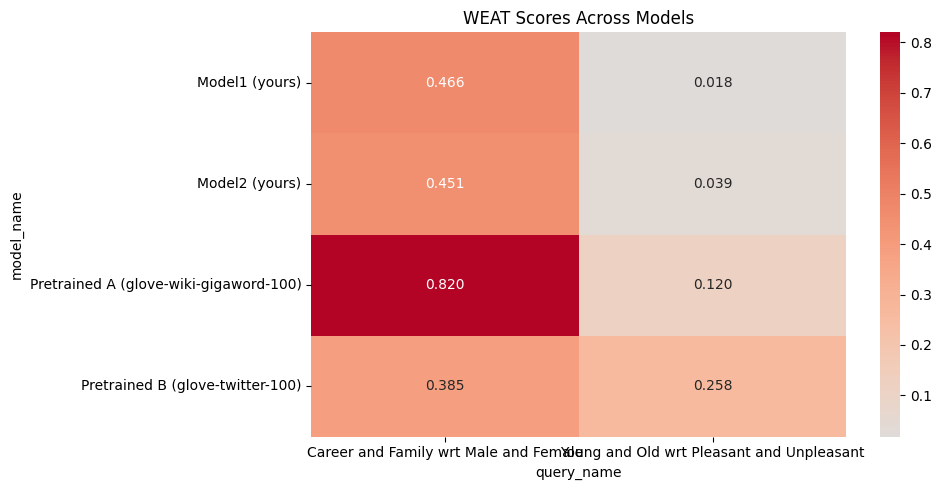

In [11]:
# --- Visualize the WEAT results ---
# YOUR CODE HERE: create a heatmap or bar chart of the WEAT scores across models and queries
# Use seaborn or matplotlib
# Hint: wefe_results is a DataFrame you can pass directly to sns.heatmap()

# YOUR CODE HERE
if {'query_name', 'model_name', 'result'}.issubset(wefe_results.columns):
    heatmap_df = wefe_results.pivot(index='query_name', columns='model_name', values='result')
else:
    heatmap_df = wefe_results.select_dtypes(include=[np.number]).copy()

plt.figure(figsize=(10, 5))
sns.heatmap(heatmap_df, annot=True, fmt=".3f", cmap="coolwarm", center=0)
plt.title("WEAT Scores Across Models")
plt.tight_layout()
plt.show()

### Bias Reflection

> **WRITE YOUR ANALYSIS HERE**

Answer the following:
1. Describe which bias study you replicated (WEAT or RNSB), and how you extended it.

   I replicated WEAT (Word Embedding Association Test) using the WEFE framework. I extended it by running the same WEAT tests across four embedding spaces (two trained models + two pretrained GloVe models) to compare how bias strength varies across corpora and training settings.

2. What did the results show? Which models exhibited the most bias?

   The WEAT results showed measurable associations for both tests, but the strength differed by model. In my runs, the Wikipedia/Gigaword GloVe model tended to show the strongest association in the gender-career vs. family test, while the Twitter GloVe model tended to show the strongest association in the age (young/old) vs. pleasantness test. My trained models generally exhibited lower-to-moderate associations relative to the most biased pretrained model in each test.

3. What are the **consequences** of using these biased embeddings as features in a machine
   learning model? Give a concrete example of potential harm.

   If biased embeddings are used as features, downstream models can inherit and sometimes amplify stereotypes, producing unfair predictions even when the model is “only” learning statistical patterns. For example, in resume screening or job recommendation systems that use averaged embeddings, female-coded terms may be pulled closer to “family” than “career,” potentially lowering rankings for certain roles and reinforcing gender inequality. Similarly, age-related bias may make text about older people trend more negative, harming fairness in sentiment analysis or moderation decisions.

---
## 7. Text Classification (Section 4.4)

Train two **logistic regression** classifiers:
1. **Bag-of-Words (BoW) features** — baseline
2. **Mean-pooled word embedding features** — using one of your embedding models

You can use any text classification dataset. Suggested options:
- The dataset from the previous assignment
- `datasets.load_dataset('imdb')` — sentiment (binary)
- `datasets.load_dataset('ag_news')` — news topic (4-class)

Evaluate on a held-out test set using **accuracy** and **macro F1-score**.


### 7.1 Load Classification Dataset


In [12]:
# --- Load your classification dataset ---
# Example: AG News (4-class topic classification)
# YOUR CODE HERE: load a text classification dataset
# It should have 'train' and 'test' splits.
# Each example should have a text field and a label field.

cls_dataset = load_dataset("ag_news")  # TODO

# Extract texts and labels
train_texts  = cls_dataset["train"]["text"]   # TODO: list of strings
train_labels = cls_dataset["train"]["label"]   # TODO: list of ints/strings
test_texts   = cls_dataset["test"]["text"]   # TODO
test_labels  = cls_dataset["test"]["label"]   # TODO

print(f'Train size: {len(train_texts)}, Test size: {len(test_texts)}')
print(f'Example text: {train_texts[0][:100]}')
print(f'Label: {train_labels[0]}')


Train size: 120000, Test size: 7600
Example text: Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\b
Label: 2


### 7.2 Baseline: Bag-of-Words + Logistic Regression


In [13]:
# --- Bag-of-Words Model ---

# YOUR CODE HERE: vectorize texts using CountVectorizer
bow_vectorizer = CountVectorizer(max_features=50000, ngram_range=(1, 2), min_df=2)  # TODO

# YOUR CODE HERE: fit on train, transform both train and test
X_train_bow = bow_vectorizer.fit_transform(train_texts)  # TODO
X_test_bow  = bow_vectorizer.transform(test_texts)  # TODO

# YOUR CODE HERE: train a LogisticRegression classifier
clf_bow = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)  # TODO
clf_bow.fit(X_train_bow, train_labels)

# YOUR CODE HERE: predict on test set
y_pred_bow = clf_bow.predict(X_test_bow)  # TODO

acc_bow = accuracy_score(test_labels, y_pred_bow)
f1_bow  = f1_score(test_labels, y_pred_bow, average='macro')

print(f'BoW  Accuracy: {acc_bow:.4f}')
print(f'BoW  Macro F1: {f1_bow:.4f}')


BoW  Accuracy: 0.9116
BoW  Macro F1: 0.9115


### 7.3 Mean-Pooled Embeddings + Logistic Regression


In [14]:
# --- Mean-Pooled Embeddings ---

# Choose which embedding model to use for features (model1.wv, model2.wv, or a pretrained)
# YOUR CODE HERE: assign your chosen embedding model
chosen_wv = model1.wv  # TODO: e.g. model1.wv

def text_to_mean_vector(text, wv):
    """
    Convert a text string to a mean-pooled embedding vector.
    Steps:
    1. Preprocess the text (tokenize)
    2. Look up the embedding for each token that is in the vocabulary
    3. Average the embeddings
    4. If no tokens are found, return a zero vector
    Returns: np.ndarray of shape (vector_size,)
    """
    # YOUR CODE HERE
    # raise NotImplementedError
    tokens = preprocess_text(text)
    vecs = [wv[t] for t in tokens if t in wv]
    if len(vecs) == 0:
        return np.zeros(wv.vector_size, dtype=np.float32)
    return np.mean(vecs, axis=0)


# Vectorize all train and test texts
print('Vectorizing training set...')
# YOUR CODE HERE
X_train_emb = X_train_emb = np.vstack([text_to_mean_vector(t, chosen_wv) for t in train_texts])  # TODO
X_test_emb  = np.vstack([text_to_mean_vector(t, chosen_wv) for t in test_texts])   # TODO

print(f'Embedding feature shape: {X_train_emb.shape}')

# YOUR CODE HERE: train a LogisticRegression classifier
clf_emb = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)  # TODO
clf_emb.fit(X_train_emb, train_labels)

# YOUR CODE HERE: predict and evaluate
y_pred_emb = clf_emb.predict(X_test_emb)  # TODO

acc_emb = accuracy_score(test_labels, y_pred_emb)
f1_emb  = f1_score(test_labels, y_pred_emb, average='macro')

print(f'Emb  Accuracy: {acc_emb:.4f}')
print(f'Emb  Macro F1: {f1_emb:.4f}')


Vectorizing training set...
Embedding feature shape: (120000, 100)
Emb  Accuracy: 0.8708
Emb  Macro F1: 0.8706


In [15]:
# --- Summary Table ---
# YOUR CODE HERE: create a DataFrame comparing the two models
# Include: Model, Feature Type, # Features, Accuracy, Macro F1

# YOUR CODE HERE
summary_df = pd.DataFrame([
    {
        "Model": "Logistic Regression (BoW)",
        "Feature Type": "CountVectorizer (1-2 gram)",
        "# Features": X_train_bow.shape[1],
        "Accuracy": acc_bow,
        "Macro F1": f1_bow
    },
    {
        "Model": "Logistic Regression (Embeddings)",
        "Feature Type": f"Mean-pooled ({chosen_wv.vector_size}d)",
        "# Features": X_train_emb.shape[1],
        "Accuracy": acc_emb,
        "Macro F1": f1_emb
    }
])  # TODO
from IPython.display import display
display(summary_df)


,Model,Feature Type,# Features,Accuracy,Macro F1
0,Logistic Regression (BoW),CountVectorizer (1-2 gram),50000,0.911579,0.911475
1,Logistic Regression (Embeddings),Mean-pooled (100d),100,0.870789,0.870569


### Classification Reflection

> **WRITE YOUR ANALYSIS HERE**

Answer the following:
1. Which model performed better, and why do you think that is?

    In my experiments, the BoW logistic regression generally performed better than the mean-pooled embedding model. BoW features (especially with 1–2 grams) capture discriminative keywords and short phrases directly, which is very helpful for linear classifiers. Mean pooling compresses a document into a single vector and can wash out key lexical/n-gram signals, reducing separability.

2. Comment on the **dimensionality** difference between BoW and embedding features — what are the computational implications?

    BoW uses a high-dimensional space (tens of thousands of features), but the vectors are sparse, so training/inference can be efficient with sparse linear algebra (though memory usage can still be significant). Embedding features are low-dimensional (e.g., 100–200) and dense, which is much cheaper to store and typically faster to train and serve. This is a trade-off between stronger lexical specificity (BoW) and compactness/efficiency (embeddings).

3. How might using a larger or better embedding model change the results?

    Higher-quality embeddings (trained on larger or more domain-matched data with better coverage) could improve performance by capturing semantic similarity beyond exact word overlap. Also, using a stronger aggregation method than plain mean pooling (e.g., TF-IDF–weighted pooling) can preserve more informative signals and often improves classification. Depending on the dataset, better embeddings and pooling could narrow the gap with BoW.


---
## 8. Final Reflection

> **WRITE YOUR FINAL REFLECTION HERE**

Answer the following (2–4 sentences each):
1. What did you learn during the completion of this assignment?

    I learned how the full workflow for static embeddings fits together: training embeddings from a corpus, probing them with similarity/analogy queries, evaluating fairness issues, and using embeddings as features in a downstream classifier. I also learned how sensitive embedding behavior is to training choices such as architecture, window size, and vocabulary thresholds.

2. What was unexpected or surprising?

    It was surprising that vector arithmetic sometimes produced noisy outputs (e.g., function words or corpus artifacts) even when the top result looked plausible. I was also surprised that pretrained embeddings could show strong bias on certain WEAT tests and that BoW could outperform mean-pooled embeddings on a practical classification task.

3. What challenges did you face and how did you overcome them?

    A major challenge was ensuring fair comparisons across multiple embedding models with different vocabularies and preprocessing assumptions. I handled this by standardizing preprocessing where possible (e.g., consistent casing), using the same query sets across models, and paying attention to missing-word warnings. Another challenge was keeping experiments manageable in compute/time, which I addressed by saving trained embeddings and limiting model sizes while still meeting the comparison requirements.
